In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置随机种子（保证结果可复现）
np.random.seed(42)

# ========== 1. 生成三簇二维正态分布数据 ==========
# 簇1：中心(0, 20)，协方差控制分布形状
cluster1 = np.random.multivariate_normal(
    mean=[0, 20],        # 簇中心（V1, V2）
    cov=[[50, 10], [10, 50]],  # 协方差矩阵（控制分布范围/形状）
    size=500             # 每簇样本数
)

# 簇2：中心(40, 60)
cluster2 = np.random.multivariate_normal(
    mean=[40, 60],
    cov=[[50, 3], [3, 50]],
    size=500
)

# 簇3：中心(70, 10)
cluster3 = np.random.multivariate_normal(
    mean=[70, 10],
    cov=[[50, 4], [4, 50]],
    size=500
)

# 合并三簇数据
all_data = np.vstack([cluster1, cluster2, cluster3])

# ========== 2. 构造DataFrame并保存为CSV ==========
df = pd.DataFrame({
    "V1": all_data[:, 0],   # 第一列：V1
    "V2": all_data[:, 1],   # 第二列：V2
    "labels": np.concatenate([  # 第三列：簇标签（0/1/2，方便验证聚类结果）
        np.zeros(500),   # 簇1标签为0
        np.ones(500),    # 簇2标签为1
        2 * np.ones(500) # 簇3标签为2
    ])
})

# 保存为data.csv（无索引列）
df.to_csv("data.csv", index=False)

# ========== 3. 可视化验证（查看是否符合三簇分布） ==========
plt.scatter(df["V1"], df["V2"], c=df["labels"], cmap="viridis", alpha=0.6)
plt.title("original data")
plt.xlabel("V1")
plt.ylabel("V2")
plt.show()

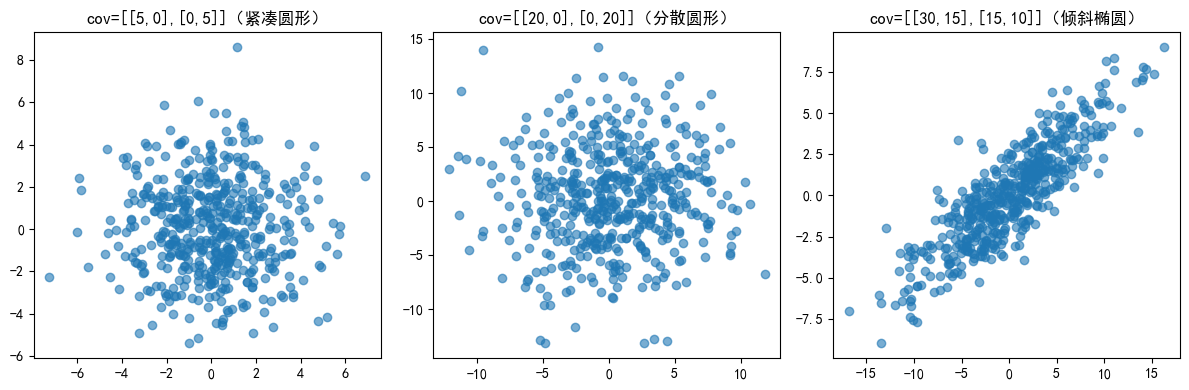

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
mean = [0, 0]  # 固定中心，只看cov的影响

# 定义3种不同的协方差矩阵
cov1 = [[5, 0], [0, 5]]    # 紧凑圆形
cov2 = [[20, 0], [0, 20]]  # 分散圆形
cov3 = [[30, 15], [15, 10]]# 倾斜椭圆

# 生成数据
data1 = np.random.multivariate_normal(mean, cov1, 500)
data2 = np.random.multivariate_normal(mean, cov2, 500)
data3 = np.random.multivariate_normal(mean, cov3, 500)

# 绘图对比
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.scatter(data1[:,0], data1[:,1], alpha=0.6)
plt.title("cov=[[5,0],[0,5]]（紧凑圆形）")

plt.subplot(132)
plt.scatter(data2[:,0], data2[:,1], alpha=0.6)
plt.title("cov=[[20,0],[0,20]]（分散圆形）")

plt.subplot(133)
plt.scatter(data3[:,0], data3[:,1], alpha=0.6)
plt.title("cov=[[30,15],[15,10]]（倾斜椭圆）")

plt.tight_layout()
plt.show()

C:\Users\何郑亚\AppData\Local\Temp\ipykernel_31208\1991534828.py:10: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  data_original = np.random.multivariate_normal(mean, cov_original, 500)
C:\Users\何郑亚\AppData\Local\Temp\ipykernel_31208\1991534828.py:15: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  data_modified = np.random.multivariate_normal(mean, cov_modified, 500)


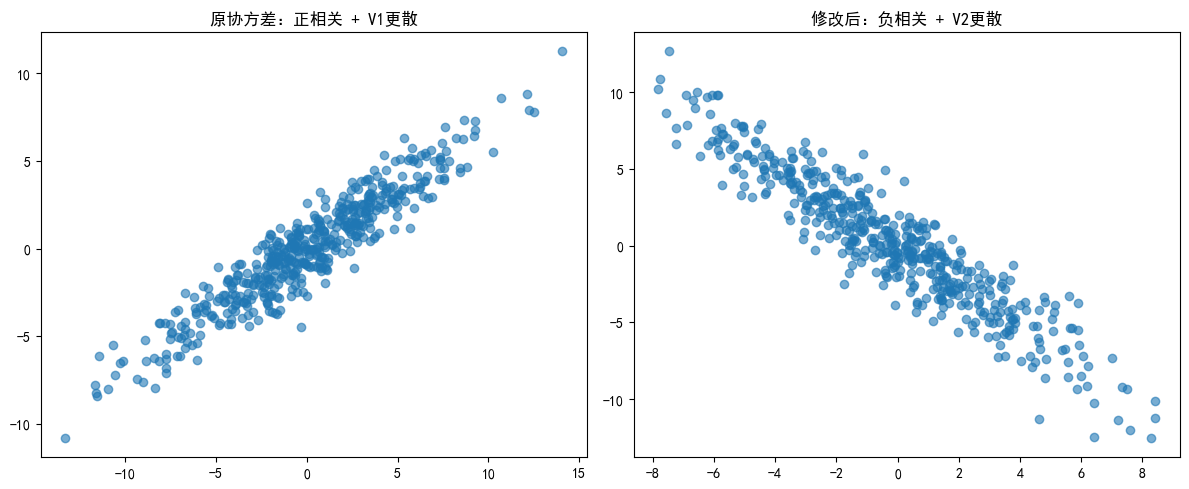

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
mean = [0, 0]  # 固定中心，只看协方差的影响

# 原协方差
cov_original = [[20, 15], 
                [15, 10]]
data_original = np.random.multivariate_normal(mean, cov_original, 500)

# 修改后的协方差
cov_modified = [[10, -15], 
                [-15, 20]]
data_modified = np.random.multivariate_normal(mean, cov_modified, 500)

# 绘图对比
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.scatter(data_original[:,0], data_original[:,1], alpha=0.6)
plt.title("原协方差：正相关 + V1更散")

plt.subplot(122)
plt.scatter(data_modified[:,0], data_modified[:,1], alpha=0.6)
plt.title("修改后：负相关 + V2更散")

plt.tight_layout()
plt.show()